# Geodesic PCA on SPD matrices with same eigenvalues

In [1]:
import os
import sys
from pathlib import Path
sys.path.append(str(Path(os.getcwd()).parent.absolute()))

In [2]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import cm

import pca.bures_wasserstein_principal_geodesic_analysis_new as pca

from geomstats.geometry.spd_matrices import SPDMatrices, SPDBuresWassersteinMetric
from tools.plot_2d import plot_results_on_cone, compare_components_on_cone, compare_first_component_on_cone_flat
from tools.compute import project, make_rotation_2d

import warnings
warnings.filterwarnings('ignore')

INFO: Using numpy backend


Generate SPD matrices with same eigenvalues.

In [3]:
np.random.seed(1)

n_points = 20
eigs = np.array([0.1 ** 2, 1. ** 2])
angles = np.linspace(np.pi / 20, np.pi - np.pi / 20, n_points)
rotations = make_rotation_2d(angles)
points_spd = np.stack([rot @ np.diag(eigs) @ rot.T for rot in rotations])

Compute geodesic PCA, print the GPCA cost for each component and visualize the components in the cone of SPD matrices.

[ 2.06562369  3.44095297 10.69215442]


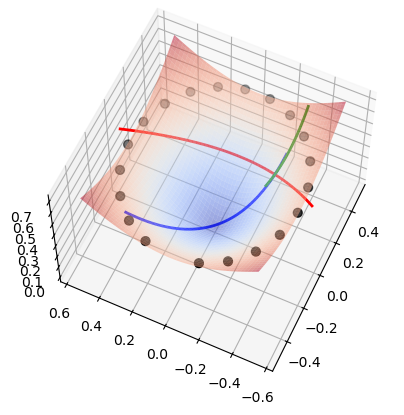

In [4]:
res_gpca = pca.BuresWassersteinPGA(dim=2).fit(points_spd)
print(res_gpca.costs)

plot_results_on_cone(
    points_spd, 
    res_gpca, 
    bound=0.5,
)

The GPCA solution is not unique: by changing the initialization, one gets different components that are equally optimal for the GPCA cost.

[ 2.06526507  3.44643335 10.69729155]


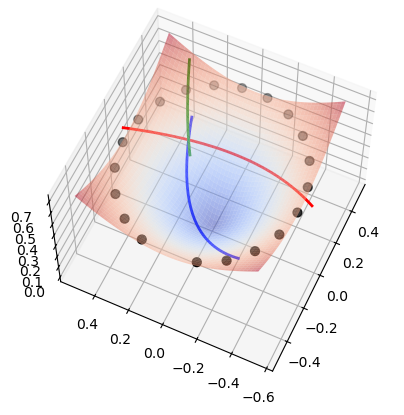

In [5]:
res_gpca = pca.BuresWassersteinPGA(dim=2, sym_matrix_init=np.ones(2)).fit(points_spd)
print(res_gpca.costs)

plot_results_on_cone(
    points_spd, 
    res_gpca, 
    bound=0.5, 
)

Compute tangent PCA and visualize the components in the cone of SPD matrices.

[3.21660916 3.74452137 8.06139556]


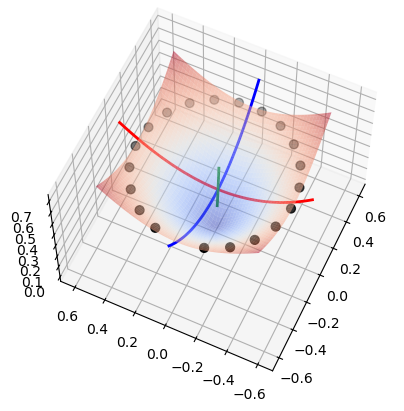

In [6]:
res_tpca = pca.BuresWassersteinTPCA().fit(points_spd)
print(res_tpca.costs)

plot_results_on_cone(
    points_spd, 
    res_tpca, 
    bound=0.5, 
)

Compare the first components of TPCA and GPCA. The first component of TPCA goes through the Fréchet mean while the GPCA component does not.

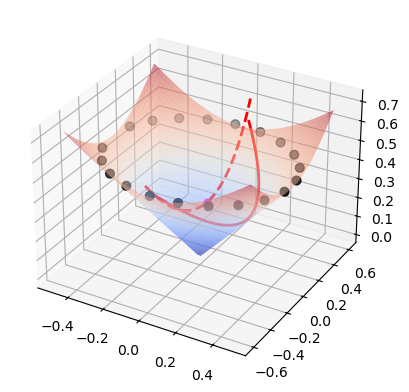

In [7]:
compare_components_on_cone(0, points_spd, res_gpca, res_tpca, bound=.5)

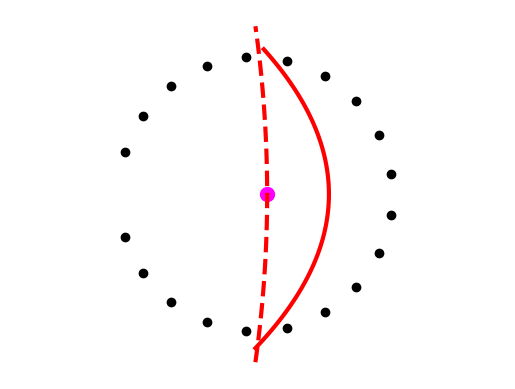

In [8]:
compare_first_component_on_cone_flat(points_spd, res_gpca, res_tpca)